# Phase 1 (notebook) — Consolidation & nettoyage des reclamations Intercom

Remplace `phase1_cleaning.py`. Etapes : fusion titre+description, correction
encodage, extraction/masquage PII (telephone, montant, reference, date),
detection de langue, lemmatisation spaCy (fr/en selon la langue).

Meme principe que `01_exploration_toutes_colonnes.ipynb` : les graphiques
representent la distribution **complete**, sans troncature ni bucket "Autres"
(voir `viz_utils.py`).

In [ ]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, ".")
sys.path.insert(0, "..")

import phase1_cleaning as p1
from viz_utils import plot_full_distribution, plot_full_counts, print_full_value_counts

PROJECT_DIR = Path("..").resolve()
RAW_CSV = PROJECT_DIR / "SRC_Intercom_Reclamation_202607201846.csv"
PHASE1_CSV = PROJECT_DIR / "reclamations_phase1.csv"

plt.rcParams["figure.dpi"] = 100

## 1. Chargement des donnees brutes

In [ ]:
df_raw = pd.read_csv(RAW_CSV, low_memory=False)
print(f"{len(df_raw)} tickets, {df_raw.shape[1]} colonnes")

18094 tickets, 67 colonnes


## 2. Disponibilite du texte libre (titre / description)

Le sentiment analysis (Phase 2) ne pourra porter que sur les tickets ayant au
moins un titre ou une description — d'ou l'importance de mesurer cette
disponibilite avant de filtrer.

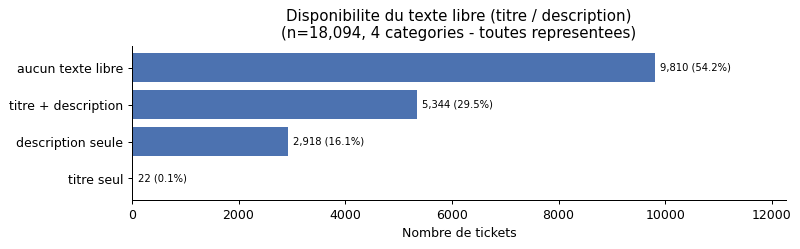

In [ ]:
has_title = df_raw["ticket_attributes__default_title_"].notna()
has_desc = df_raw["ticket_attributes__default_description_"].notna()

labels = np.select(
    [has_title & has_desc, has_title & ~has_desc, ~has_title & has_desc],
    ["titre + description", "titre seul", "description seule"],
    default="aucun texte libre",
)
_ = plot_full_distribution(pd.Series(labels), "Disponibilite du texte libre (titre / description)")
plt.show()

## 3. Nettoyage : fusion texte, masquage PII, langue, lemmatisation

Si `reclamations_phase1.csv` existe deja (calcule precedemment via
`phase1_cleaning.py`), on le charge directement — la lemmatisation spaCy sur
l'ensemble des tickets prend du temps et le resultat est deterministe, pas
besoin de la relancer a chaque ouverture du notebook. Le code de recalcul
complet reste ci-dessous, executable si le fichier est absent.

In [ ]:
if PHASE1_CSV.exists():
    print(f"Cache trouve : {PHASE1_CSV.name} -> chargement (evite de relancer spaCy).")
    df1 = pd.read_csv(PHASE1_CSV, low_memory=False)
else:
    print("Pas de cache : execution du pipeline de nettoyage (spaCy, peut prendre plusieurs minutes)...")
    df1 = df_raw[p1.COLUMNS_TO_KEEP].copy()
    has_text_mask = (
        df1["ticket_attributes__default_title_"].notna()
        | df1["ticket_attributes__default_description_"].notna()
    )
    df1 = df1[has_text_mask].reset_index(drop=True)

    title = df1["ticket_attributes__default_title_"].fillna("").map(p1.fix_encoding)
    desc = df1["ticket_attributes__default_description_"].fillna("").map(p1.fix_encoding)
    df1["texte"] = (title + ". " + desc).str.strip(". ").str.replace(r"^\.\s*", "", regex=True)

    extracted = df1["texte"].map(p1.extract_and_mask)
    df1["texte_masque"] = extracted.map(lambda t: t[0])
    df1["pii_telephones"] = extracted.map(lambda t: ";".join(t[1]) if t[1] else "")
    df1["pii_dates"] = extracted.map(lambda t: ";".join(t[2]) if t[2] else "")
    df1["pii_references"] = extracted.map(lambda t: ";".join(t[3]) if t[3] else "")
    df1["pii_montants"] = extracted.map(lambda t: ";".join(t[4]) if t[4] else "")

    df1["langue"] = df1["texte_masque"].map(p1.detect_language)
    df1["texte_lemmatise"] = p1.lemmatize_by_language(df1, "texte_masque", "langue")

    df1.to_csv(PHASE1_CSV, index=False)
    print(f"Ecrit : {PHASE1_CSV.name}")

print(f"{len(df1)} tickets avec texte libre retenus pour la suite (sur {len(df_raw)} au total).")
df1.head(3)

Cache trouve : reclamations_phase1.csv -> chargement (evite de relancer spaCy).
8284 tickets avec texte libre retenus pour la suite (sur 18094 au total).


## 4. Detection de la langue — distribution complete

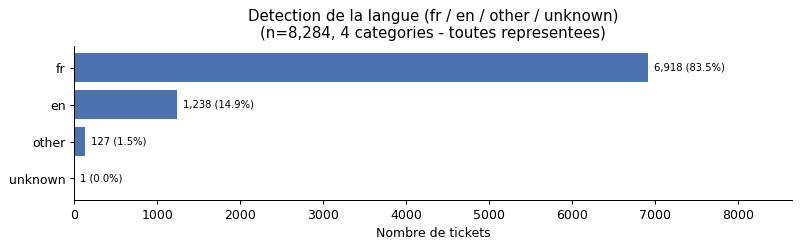

In [ ]:
_ = plot_full_distribution(df1["langue"], "Detection de la langue (fr / en / other / unknown)")
plt.show()

## 5. Types de reclamation parmi les tickets avec texte libre

A comparer avec la repartition brute (section 0 de `01_exploration_toutes_colonnes.ipynb`) :
le filtre "texte disponible" ne touche pas toutes les categories de la meme
maniere, ce qui doit rester visible plutot que suppose.

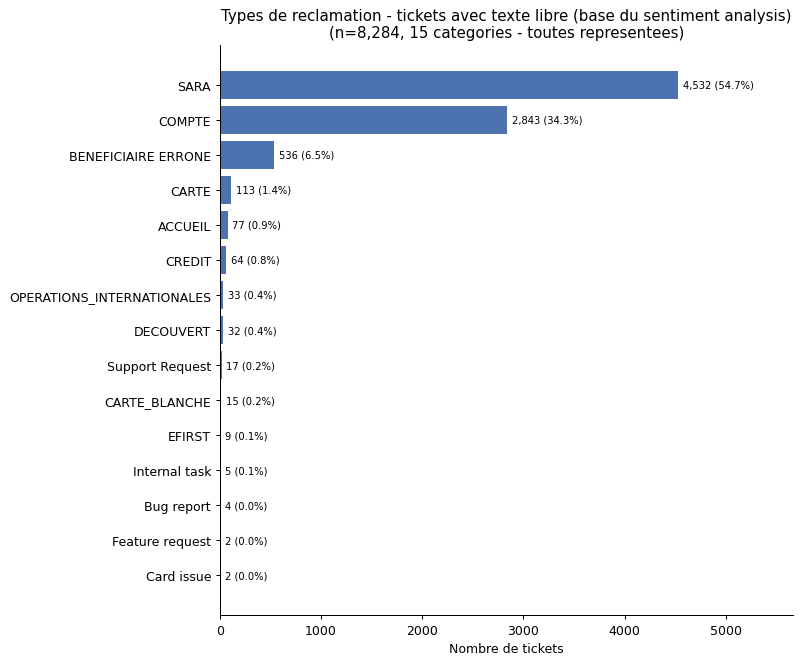

In [ ]:
_ = plot_full_distribution(df1["ticket_type_name"], "Types de reclamation - tickets avec texte libre (base du sentiment analysis)")
plt.show()

## 6. Longueur du texte nettoye (`texte_masque`)

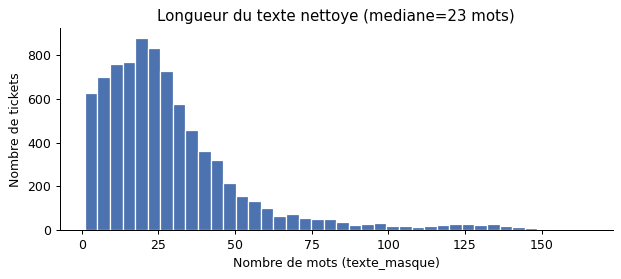

In [ ]:
longueurs = df1["texte_masque"].fillna("").str.split().map(len)
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(longueurs, bins=40, color="#4C72B0", edgecolor="white")
ax.set_xlabel("Nombre de mots (texte_masque)")
ax.set_ylabel("Nombre de tickets")
ax.set_title(f"Longueur du texte nettoye (mediane={int(longueurs.median())} mots)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
plt.show()

## 7. PII extraite (telephone / date / reference / montant)

Combien de tickets contiennent chaque type d'information personnelle
identifiable, masquee dans `texte_masque` et extraite dans des colonnes
dediees (utile pour l'objectif A : parametres utiles a la banque).

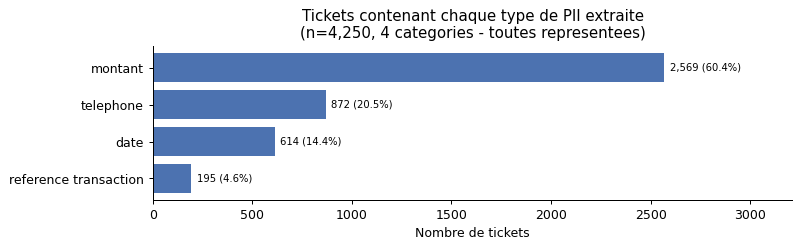

In [ ]:
pii_presence = pd.Series({
    "telephone": (df1["pii_telephones"].fillna("") != "").sum(),
    "date": (df1["pii_dates"].fillna("") != "").sum(),
    "reference transaction": (df1["pii_references"].fillna("") != "").sum(),
    "montant": (df1["pii_montants"].fillna("") != "").sum(),
})
_ = plot_full_counts(pii_presence, "Tickets contenant chaque type de PII extraite", xlabel="Nombre de tickets", pct=True, value_fmt="{:,.0f}")
plt.show()